# A08 — Data Augmentation para imagens ASTER
&emsp;&emsp;Data augmentation é uma técnica que amplia artificialmente o conjunto de treinamento por meio de transformações controladas nas imagens, aumentando a variabilidade dos dados e reduzindo overfitting.  
Para imagens ASTER, foram escolhidos rotações, flip, crop e ruído gaussiano para ampliar o conjunto

### Justificativa para transformações aplicadas

&emsp;&emsp;Imagens ASTER (Advanced Spaceborne Thermal Emission and Reflection Radiometer) apresentam variabilidade espacial e radiométrica decorrente de diferentes condições de aquisição orbital, geometria de observação e resposta espectral do sensor. Em tarefas de classificação com redes neurais convolucionais, técnicas de *data augmentation* são importantes para ampliar artificialmente a diversidade do conjunto de treinamento, reduzindo overfitting e aumentando a capacidade de generalização do modelo frente a pequenas variações presentes em dados reais.

&emsp;&emsp;Entre as transformações selecionadas, a rotação foi aplicada em pequena intensidade para simular variações angulares compatíveis com deslocamentos de aquisição sem comprometer a morfologia espacial dos alvos observados. O flip horizontal foi incluído para aumentar a variabilidade geométrica quando a orientação absoluta não constitui atributo discriminativo da classe analisada. O crop (recorte aleatório seguido de redimensionamento) contribui para robustez espacial ao expor o modelo a diferentes regiões locais da imagem, enquanto a adição de ruído gaussiano simula pequenas perturbações radiométricas associadas ao sensor e às condições atmosféricas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import sys
import pandas as pd

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Carregamento dos dados

In [2]:
repo_root = Path.cwd()

while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [3]:
from src.models.cnn_data_prep import prepare_cnn_inputs

In [4]:
DATASET_PATH = repo_root / 'outputs' / 'pixels_dataset.csv'
CODES_PATH = repo_root / 'data' / 'extracted_codes.json'
NORMALIZER_PATH = repo_root / 'outputs' / 'a04_cnn_data_prep' / 'cnn_normalizer_zscore.npz'

print("Carregando dataset de pixels...")

df = pd.read_csv(DATASET_PATH)

Carregando dataset de pixels...


### Preparação das entradas para CNN

&emsp;&emsp;A função `prepare_cnn_inputs` organiza os dados no formato esperado pela rede convolucional, preservando a estrutura espacial das imagens ASTER e removendo amostras com rótulos inválidos.

In [5]:
probe = prepare_cnn_inputs(
    df,
    extracted_codes_path=CODES_PATH,
    normalization='none',
    data_format='channels_last',
    drop_invalid_labels=False,
)

X = probe['X']
y = probe['y']

valid_mask = y != -1
X = X[valid_mask]
y = y[valid_mask]

normalizer = np.load(NORMALIZER_PATH)
mean = normalizer['mean']
std = normalizer['std']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (295, 128, 128, 9)
Shape y: (295,)


## 2. Pipeline de augmentation

- **Rotação leve (±15°)** → preserva orientação orbital sem distorção extrema  
- **Flip horizontal** → útil quando classe não depende de direção absoluta  
- **Random crop** → aumenta invariância espacial  
- **Ruído gaussiano leve** → simula variação radiométrica


In [6]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),      # ~ ±15°
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomCrop(120, 120),
    tf.keras.layers.Resizing(128, 128),
    tf.keras.layers.GaussianNoise(0.02)
])

## 3. Aplicação em amostra visual

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

sample = X[0:1].astype(np.float32)

rgb_bands = [0, 1, 2]

augmented = [
    tf.keras.layers.RandomRotation(0.08)(sample, training=True)[0].numpy(),
    tf.keras.layers.RandomFlip("horizontal")(sample, training=True)[0].numpy(),
    tf.keras.Sequential([
        tf.keras.layers.RandomCrop(120, 120),
        tf.keras.layers.Resizing(128, 128)
    ])(sample, training=True)[0].numpy(),
    tf.keras.layers.GaussianNoise(0.02)(sample, training=True)[0].numpy()
]

labels = ["Rotação", "Flip", "Crop", "Ruído"]

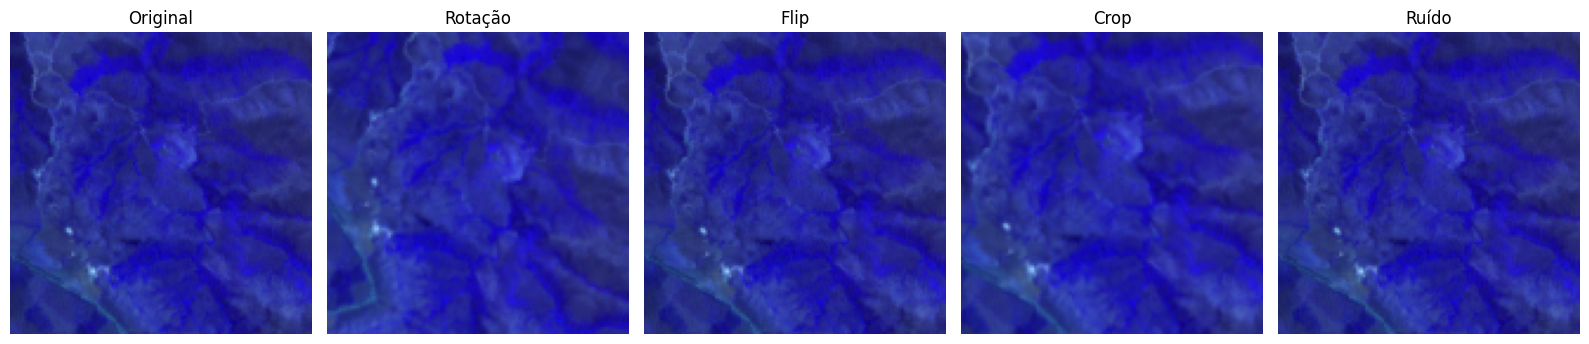

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# original
orig = sample[0][:, :, rgb_bands]
orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)

axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis("off")

# augmentações
for i, img in enumerate(augmented):
    vis = img[:, :, rgb_bands]
    vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)

    axes[i+1].imshow(vis)
    axes[i+1].set_title(labels[i])
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

## Integração com `tf.data`

&emsp;&emsp;A API `tf.data` permite construir pipelines eficientes de entrada de dados no TensorFlow, organizando carregamento, batching e transformações de forma automática durante o treinamento. Nesse contexto, o data augmentation pode ser aplicado dinamicamente a cada lote de imagens, fazendo com que novas variações sejam geradas a cada época sem modificar permanentemente o conjunto original.

In [9]:
dataset = tf.data.Dataset.from_tensor_slices(X)

train_ds = (
    dataset
    .shuffle(len(X))
    .batch(4)
    .map(lambda x: augmentation(x, training=True))
    .prefetch(tf.data.AUTOTUNE)
)

for batch in train_ds.take(1):
    print("Batch shape:", batch.shape)

Batch shape: (4, 128, 128, 9)


### Validando a distribuição espectral

In [10]:
orig_mean = sample[0].mean(axis=(0,1))

for i, img in enumerate(augmented):
    aug_mean = img.mean(axis=(0,1))

    diff = np.abs(orig_mean - aug_mean)

    print(f"{labels[i]}")
    print("Diferença média por banda:", diff[:10])  # primeiras bandas
    print()

Rotação
Diferença média por banda: [0.7990837  1.2608223  0.07766724 1.5484772  1.15094    1.2958832
 1.2018433  0.8907013  0.5323868 ]

Flip
Diferença média por banda: [0. 0. 0. 0. 0. 0. 0. 0. 0.]

Crop
Diferença média por banda: [0.08602905 0.17036057 2.0524445  0.671402   0.5616913  0.7288208
 0.42063904 0.35182953 0.2467804 ]

Ruído
Diferença média por banda: [1.1444092e-05 3.4332275e-05 1.2207031e-04 1.5258789e-05 0.0000000e+00
 9.1552734e-05 1.2207031e-04 1.3732910e-04 1.8310547e-04]



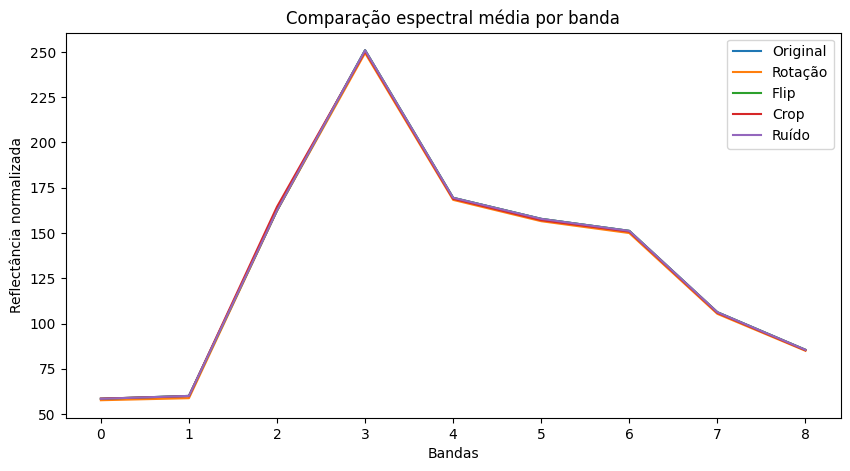

In [11]:
plt.figure(figsize=(10,5))

plt.plot(orig_mean, label="Original")

for i, img in enumerate(augmented):
    aug_mean = img.mean(axis=(0,1))
    plt.plot(aug_mean, label=labels[i])

plt.legend()
plt.title("Comparação espectral média por banda")
plt.xlabel("Bandas")
plt.ylabel("Reflectância normalizada")
plt.show()

&emsp;&emsp;A comparação das curvas espectrais médias por banda mostra que todas as transformações de data augmentation mantiveram a assinatura espectral global muito próxima da imagem original, indicando preservação da informação relevante para o modelo.

Flip horizontal:
Não houve qualquer diferença entre os valores médios das bandas (diferença zero em todas as bandas), o que confirma que a operação apenas reorganiza a posição espacial dos pixels sem alterar conteúdo espectral.

Rotação:
As diferenças médias por banda variaram aproximadamente entre 0.08 e 1.55 unidades. Considerando bandas com reflectância entre ~58 e ~250, isso representa erro relativo inferior a 1% na maior parte das bandas. Essas pequenas diferenças são esperadas devido à interpolação realizada durante a rotação.

Crop:
A maior diferença observada foi cerca de 2.05 unidades, ainda sobre bandas cuja magnitude chega a 250. Isso corresponde a erro relativo inferior a 1%, indicando que o recorte altera ligeiramente a média por remover pequenas regiões espaciais, mas preserva o comportamento espectral geral.

Ruído gaussiano:
As diferenças ficaram na ordem de 10^-5 a 10^-4, praticamente nulas em relação à escala dos dados. Isso demonstra que o ruído aplicado foi suficientemente pequeno para não comprometer a assinatura espectral.

&emsp;&emsp;De forma geral, todas as augmentations aplicadas apresentam impacto espectral muito baixo (<1%), sendo adequadas para aumentar a variabilidade espacial do conjunto de treino sem degradar a informação espectral necessária para classificação.

In [13]:
for i, img in enumerate(augmented):
    aug_mean = img.mean(axis=(0,1))
    rel = np.mean(np.abs(orig_mean - aug_mean) / orig_mean) * 100
    print(f"{labels[i]} -> erro relativo médio: {rel:.3f}%")

Rotação -> erro relativo médio: 0.876%
Flip -> erro relativo médio: 0.000%
Crop -> erro relativo médio: 0.406%
Ruído -> erro relativo médio: 0.000%


## Conclusão

&emsp;&emsp;A análise das transformações aplicadas mostra que as augmentations escolhidas conseguem aumentar a variabilidade das imagens sem alterar de forma significativa a informação espectral média das bandas. Visualmente, as curvas espectrais antes e depois das transformações permaneceram muito próximas, o que indica que a assinatura espectral principal foi preservada.

&emsp;&emsp;No flip horizontal, não houve diferença entre os valores médios das bandas, já que a transformação apenas muda a disposição espacial dos pixels. Na rotação, as diferenças ficaram entre aproximadamente 0,08 e 1,55 unidades por banda; considerando que algumas bandas apresentam valores próximos de 250, esse impacto permanece abaixo de 1% e pode ser atribuído ao processo de interpolação. No crop, a maior diferença observada foi de cerca de 2,05 unidades, também inferior a 1% em relação à escala geral dos dados, mostrando que o recorte altera apenas pequenas regiões locais sem modificar o comportamento espectral global. Já o ruído gaussiano apresentou diferenças praticamente nulas, na ordem de 10⁻⁵ a 10⁻⁴.

&emsp;&emsp;De forma geral, as transformações se mostraram adequadas para uso no treinamento, pois introduzem variações espaciais controladas e mantêm a consistência espectral necessária para a CNN aprender padrões relevantes. Além disso, a aplicação via tf.data permite que essas alterações ocorram apenas no conjunto de treino, mantendo validação e teste sem interferência.